In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("../data/raw/smart traffic data.csv")
df.head()

,Product ID,Product Name,Category,Warehouse,Location,Quantity,Price,Supplier,Status,Last Restocked
0,1102,gadget y,ELECTRONICS,Warehouse 2,Aisle 1,300,9.99,Supplier C,In Stock,NaN
1,1435,gadget y,ELECTRONICS,Warehouse 2,Aisle 4,two hundred,19.99,Supplier C,Out of Stock,NaN
2,1860,widget a,CLOTHING,Warehouse 2,Aisle 3,100,19.99,Supplier B,In Stock,20/12/2022
3,1270,gadget z,TOYS,Warehouse 2,Aisle 4,50,49.99,Supplier B,In Stock,20/12/2022
4,1106,widget a,FURNITURE,Warehouse 3,Aisle 3,two hundred,9.99,Supplier D,Out of Stock,25/04/2023


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Product ID      1000 non-null   int64  
 1   Product Name    1000 non-null   str    
 2   Category        1000 non-null   str    
 3   Warehouse       1000 non-null   str    
 4   Location        1000 non-null   str    
 5   Quantity        842 non-null    str    
 6   Price           793 non-null    float64
 7   Supplier        1000 non-null   str    
 8   Status          1000 non-null   str    
 9   Last Restocked  800 non-null    str    
dtypes: float64(1), int64(1), str(8)
memory usage: 78.3 KB


In [7]:
df.describe()

,Product ID,Price
count,1000.000000,793.000000
mean,1503.929000,28.085839
std,289.998108,14.686312
min,1000.000000,9.990000
25%,1242.750000,19.990000
50%,1505.000000,29.990000
75%,1757.250000,49.990000
max,1998.000000,49.990000


In [8]:
df.isnull().sum()

Product ID          0
Product Name        0
Category            0
Warehouse           0
Location            0
Quantity          158
Price             207
Supplier            0
Status              0
Last Restocked    200
dtype: int64

In [9]:
#for duplicate rows
duplicates = df.duplicated().sum()
print("Duplicates:", duplicates)

Duplicates: 0


In [11]:
print(df["Warehouse"].unique())

<StringArray>
['Warehouse 2', 'Warehouse 3', 'Warehouse 1']
Length: 3, dtype: str


In [12]:
print(df.dtypes)

Product ID          int64
Product Name          str
Category              str
Warehouse             str
Location              str
Quantity              str
Price             float64
Supplier              str
Status                str
Last Restocked        str
dtype: object


In [15]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

In [16]:
text_cols = df.select_dtypes(include="object").columns
for col in text_cols:
    df[col] = df[col].astype(str).str.strip().str.lower()

C:\Users\USER\AppData\Local\Temp\ipykernel_4584\1390641375.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = df.select_dtypes(include="object").columns


In [17]:
df["price"] = (
    df["price"]
    .astype(str)
    .str.replace(r"[^0-9.]", "", regex=True)
)
df["price"] = pd.to_numeric(df["price"], errors="coerce")

In [18]:
df["price"].fillna(df["price"].median(), inplace=True)

C:\Users\USER\AppData\Local\Temp\ipykernel_4584\2043421642.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["price"].fillna(df["price"].median(), inplace=True)


0       9.99
1      19.99
2      19.99
3      49.99
4       9.99
       ...  
995    29.99
996    19.99
997     9.99
998    49.99
999    49.99
Name: price, Length: 1000, dtype: float64

In [19]:
df.drop_duplicates(inplace=True)

In [20]:
df = df[df["price"] >= 0]

In [21]:
print(df.info())

<class 'pandas.DataFrame'>
Index: 793 entries, 0 to 999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      793 non-null    int64  
 1   product_name    793 non-null    str    
 2   category        793 non-null    str    
 3   warehouse       793 non-null    str    
 4   location        793 non-null    str    
 5   quantity        661 non-null    str    
 6   price           793 non-null    float64
 7   supplier        793 non-null    str    
 8   status          793 non-null    str    
 9   last_restocked  623 non-null    str    
dtypes: float64(1), int64(1), str(8)
memory usage: 68.1 KB
None


In [22]:
print(df.isnull().sum())

product_id          0
product_name        0
category            0
warehouse           0
location            0
quantity          132
price               0
supplier            0
status              0
last_restocked    170
dtype: int64


In [23]:
print(df.describe())

        product_id       price
count   793.000000  793.000000
mean   1500.678436   28.085839
std     289.037883   14.686312
min    1000.000000    9.990000
25%    1243.000000   19.990000
50%    1504.000000   29.990000
75%    1751.000000   49.990000
max    1998.000000   49.990000


In [24]:
failure_counts = df.isnull().sum()
print(failure_counts)

product_id          0
product_name        0
category            0
warehouse           0
location            0
quantity          132
price               0
supplier            0
status              0
last_restocked    170
dtype: int64


In [28]:
df["quantity"] = (
    df["quantity"]
    .astype(str)
    .str.replace(r"[^0-9.-]", "", regex=True)
)

In [29]:
df["quantity"] = pd.to_numeric(
    df["quantity"],
    errors="coerce"
)

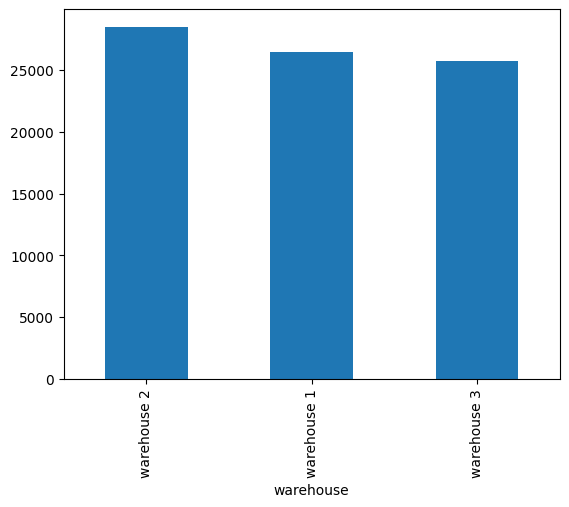

In [30]:
hub_activity = df.groupby("warehouse")["quantity"].sum()
hub_activity.sort_values(ascending=False).plot(kind="bar")
plt.show()

In [26]:
error_rate = df.groupby("category").apply(
    lambda x: x.isnull().sum().sum()
)
print(error_rate)

category
clothing       88
electronics    68
furniture      75
toys           71
dtype: int64


In [27]:
df.to_csv("cleaned smart traffic data.csv",
    index=False)

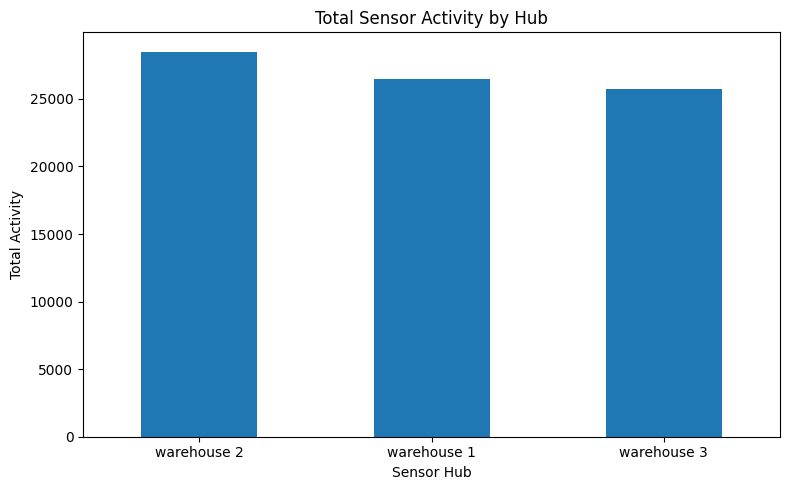

In [31]:
import matplotlib.pyplot as plt
hub_activity = df.groupby("warehouse")["quantity"].sum()
hub_activity = hub_activity.sort_values(ascending=False)
plt.figure(figsize=(8,5))
hub_activity.plot(kind="bar")
plt.title("Total Sensor Activity by Hub")
plt.xlabel("Sensor Hub")
plt.ylabel("Total Activity")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()